In [5]:
import os, json
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def cxcywh_to_xyxy(cxcywh: torch.Tensor) -> torch.Tensor:
    cx, cy, w, h = cxcywh.unbind(-1)
    x1 = cx - 0.5 * w
    y1 = cy - 0.5 * h
    x2 = cx + 0.5 * w
    y2 = cy + 0.5 * h
    return torch.stack([x1, y1, x2, y2], dim=-1)

In [6]:
class PositionEmbeddingSine(nn.Module):
    def __init__(self, num_pos_feats=128, temperature=10000):
        super().__init__()
        self.num_pos_feats = num_pos_feats
        self.temperature = temperature

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B,C,H,W]
        B, _, H, W = x.shape
        device = x.device

        y_embed = torch.linspace(0, 1, H, device=device).unsqueeze(1).repeat(1, W)
        x_embed = torch.linspace(0, 1, W, device=device).unsqueeze(0).repeat(H, 1)

        dim_t = torch.arange(self.num_pos_feats, device=device, dtype=torch.float32)
        dim_t = self.temperature ** (2 * (dim_t // 2) / self.num_pos_feats)

        pos_x = x_embed[..., None] / dim_t
        pos_y = y_embed[..., None] / dim_t

        pos_x = torch.stack((pos_x[..., 0::2].sin(), pos_x[..., 1::2].cos()), dim=3).flatten(2)
        pos_y = torch.stack((pos_y[..., 0::2].sin(), pos_y[..., 1::2].cos()), dim=3).flatten(2)

        pos = torch.cat((pos_y, pos_x), dim=2)  # [H,W,2F]
        pos = pos.permute(2, 0, 1).unsqueeze(0).repeat(B, 1, 1, 1)  # [B,2F,H,W]
        return pos


class CornetSpatialBackbone(nn.Module):
    def __init__(self, cornet_model: nn.Module, feature_layer: str = "IT"):
        super().__init__()
        self.model = cornet_model
        self.feature_layer = feature_layer
        self._feat = None

        if not hasattr(self.model, feature_layer):
            raise ValueError(f"CORnet model has no attribute '{feature_layer}'. Try: V1,V2,V4,IT")
        layer_mod = getattr(self.model, feature_layer)

        def hook_fn(module, inp, out):
            self._feat = out

        layer_mod.register_forward_hook(hook_fn)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        _ = self.model(x)
        if self._feat is None:
            raise RuntimeError("Feature hook did not capture output. Check feature_layer.")
        return self._feat


class CornetDETR_Objness(nn.Module):
    """
    Outputs:
      pred_obj_logits: [B,Q,2]   (0=NO_OBJECT, 1=OBJECT)
      pred_boxes:      [B,Q,4]   cxcywh in [0,1]
    """
    def __init__(
        self,
        cornet_base: nn.Module,
        num_queries: int = 10,
        feature_layer: str = "IT",
        d_model: int = 256,
        nhead: int = 8,
        num_decoder_layers: int = 4,
        dim_feedforward: int = 1024,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.num_queries = num_queries
        self.backbone = CornetSpatialBackbone(cornet_base, feature_layer=feature_layer)

        self.proj = None  # lazy init
        self.d_model = d_model

        self.pos_embed = PositionEmbeddingSine(num_pos_feats=d_model // 2)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward, dropout=dropout,
            batch_first=True
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_decoder_layers)

        self.query_embed = nn.Embedding(num_queries, d_model)

        self.obj_head = nn.Linear(d_model, 2)
        self.box_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 4),
        )

    def _ensure_proj(self, feat: torch.Tensor):
        if self.proj is None:
            in_ch = feat.shape[1]
            self.proj = nn.Conv2d(in_ch, self.d_model, kernel_size=1).to(feat.device)
            self.add_module("input_proj", self.proj)

    def forward(self, x: torch.Tensor):
        feat = self.backbone(x)     # [B,C,H,W]
        self._ensure_proj(feat)

        src = self.proj(feat)       # [B,d,H,W]
        pos = self.pos_embed(src)   # [B,d,H,W]

        B, d, H, W = src.shape
        src_tokens = src.flatten(2).permute(0, 2, 1)  # [B,HW,d]
        pos_tokens = pos.flatten(2).permute(0, 2, 1)  # [B,HW,d]

        q = self.query_embed.weight.unsqueeze(0).repeat(B, 1, 1)  # [B,Q,d]
        hs = self.decoder(tgt=q, memory=src_tokens + pos_tokens)  # [B,Q,d]

        obj_logits = self.obj_head(hs)                   # [B,Q,2]
        boxes = torch.sigmoid(self.box_head(hs))         # [B,Q,4]
        return {"pred_obj_logits": obj_logits, "pred_boxes": boxes}

In [7]:

CKPT_PATH = Path("/zpool/vladlab/data_drive/geogaze_data/cornet_coco_bboxes/cornetz/individuation_critical/best.pth.tar")  
CORN_NET_REPO = Path("/zpool/vladlab/active_drive/omaltz/git_repos/CORnet")  

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# Load checkpoint
ckpt = torch.load(CKPT_PATH, map_location=device)
args = ckpt.get("args", {})
print("Loaded ckpt keys:", ckpt.keys())
print("Args:", args)

# Import cornet from your local repo
import sys
if str(CORN_NET_REPO) not in sys.path:
    sys.path.insert(0, str(CORN_NET_REPO))
import cornet
print("Imported cornet from:", cornet.__file__)

# Rebuild CORnet base
model_letter = str(args.get("model", "Z")).lower()
times = int(args.get("times", 5))
feature_layer = str(args.get("feature_layer", "IT"))

base_ctor = getattr(cornet, f"cornet_{model_letter}")
if model_letter == "r":
    cornet_base = base_ctor(pretrained=False, map_location=device, times=times)
else:
    cornet_base = base_ctor(pretrained=False, map_location=device)
if hasattr(cornet_base, "module"):
    cornet_base = cornet_base.module

# Rebuild DETR head (must match training hyperparams)
model = CornetDETR_Objness(
    cornet_base=cornet_base,
    num_queries=int(args.get("num_queries", 10)),
    feature_layer=feature_layer,
    d_model=int(args.get("d_model", 256)),
    nhead=int(args.get("nhead", 8)),
    num_decoder_layers=int(args.get("num_decoder_layers", 4)),
    dim_feedforward=int(args.get("dim_feedforward", 1024)),
).to(device)

# Load weights
missing, unexpected = model.load_state_dict(ckpt["model"], strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.eval()

device: cuda
Loaded ckpt keys: dict_keys(['epoch', 'best_val', 'model', 'optimizer', 'args'])
Args: {'train_images': '/zpool/vladlab/data_drive/stimulus_sets/geogaze_COCO_stim/coco_working/working_v3/train_working3', 'train_csv': '/zpool/vladlab/data_drive/stimulus_sets/geogaze_COCO_stim/coco_working/working_v3/instances_train_filtered3_bboxes.csv', 'val_images': '/zpool/vladlab/data_drive/stimulus_sets/geogaze_COCO_stim/coco_working/working_v3/val_working3', 'val_csv': '/zpool/vladlab/data_drive/stimulus_sets/geogaze_COCO_stim/coco_working/working_v3/instances_val_filtered3_bboxes.csv', 'output_path': '/zpool/vladlab/data_drive/geogaze_data/cornet_coco_bboxes/cornetz/individuation_critical', 'model': 'Z', 'times': 5, 'feature_layer': 'V4', 'num_queries': 10, 'd_model': 256, 'nhead': 8, 'num_decoder_layers': 4, 'dim_feedforward': 1024, 'epochs': 200, 'batch_size': 8, 'workers': 4, 'lr': 0.0001, 'backbone_lr': 1e-05, 'weight_decay': 0.0001, 'ngpus': 1, 'resume': None, 'no_object_weight'

CornetDETR_Objness(
  (backbone): CornetSpatialBackbone(
    (model): Sequential(
      (V1): CORblock_Z(
        (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
        (nonlin): ReLU(inplace=True)
        (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (output): Identity()
      )
      (V2): CORblock_Z(
        (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (nonlin): ReLU(inplace=True)
        (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (output): Identity()
      )
      (V4): CORblock_Z(
        (conv): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (nonlin): ReLU(inplace=True)
        (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (output): Identity()
      )
      (IT): CORblock_Z(
        (conv): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1,

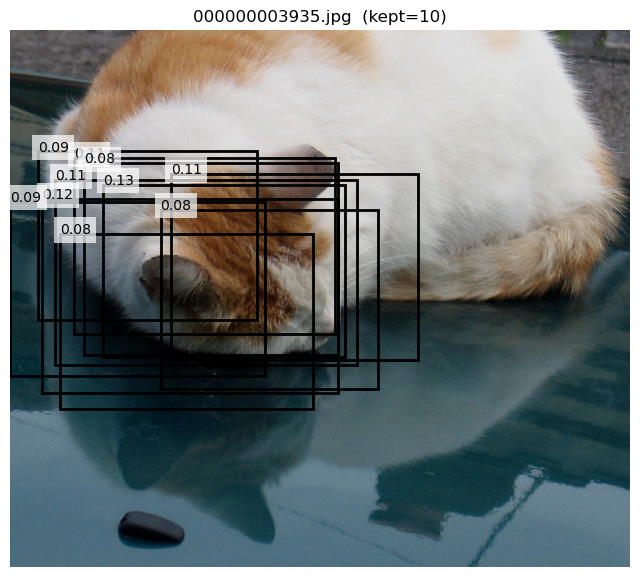

In [10]:
# CORnet-style input transform (must match training)
normalize = torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                             std=[0.229, 0.224, 0.225])
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((224, 224)),
    torchvision.transforms.ToTensor(),
    normalize,
])

def predict_boxes_on_image(img_path: str | Path, obj_thresh=0.5, topk=None):
    img_path = Path(img_path)
    im_pil = Image.open(img_path).convert("RGB")
    orig_w, orig_h = im_pil.size

    x = transform(im_pil).unsqueeze(0).to(device)  # [1,3,224,224]

    with torch.no_grad():
        out = model(x)
        obj_logits = out["pred_obj_logits"][0]  # [Q,2]
        boxes_cxcywh = out["pred_boxes"][0]     # [Q,4]

        obj_probs = obj_logits.softmax(-1)[:, 1]  # P(OBJECT), [Q]
        boxes_xyxy = cxcywh_to_xyxy(boxes_cxcywh).clamp(0, 1)  # normalized

        # filter by threshold
        keep = obj_probs >= obj_thresh
        obj_probs = obj_probs[keep]
        boxes_xyxy = boxes_xyxy[keep]

        # optionally take topk
        if topk is not None and obj_probs.numel() > topk:
            idx = torch.argsort(obj_probs, descending=True)[:topk]
            obj_probs = obj_probs[idx]
            boxes_xyxy = boxes_xyxy[idx]

    # convert to pixel coords in ORIGINAL image space
    boxes_px = boxes_xyxy.clone()
    boxes_px[:, [0, 2]] *= orig_w
    boxes_px[:, [1, 3]] *= orig_h

    return im_pil, boxes_px.cpu().numpy(), obj_probs.cpu().numpy()

def show_predictions(img_path, obj_thresh=0.5, topk=10):
    im_pil, boxes_px, scores = predict_boxes_on_image(img_path, obj_thresh=obj_thresh, topk=topk)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(im_pil)
    ax.axis("off")
    ax.set_title(f"{Path(img_path).name}  (kept={len(scores)})")

    for (x1, y1, x2, y2), s in zip(boxes_px, scores):
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=2)
        ax.add_patch(rect)
        ax.text(x1, y1, f"{s:.2f}", fontsize=10, bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

    plt.show()

show_predictions("/zpool/vladlab/data_drive/stimulus_sets/geogaze_COCO_stim/coco_working/working_v3/train_working3/000000003935.jpg", obj_thresh=0, topk=10)